<a href="https://colab.research.google.com/github/appling2024/MSP/blob/Liza/WSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy scikit-learn compress-fasttext xmltodict matplotlib

Ruwordnet -- тезаурус русского языка, содержит синсеты (наборы синонимов) существительных, глаголов и прилагательных.
Между синсетами, относящимися к разным частям речи, но выражающих один и тот же смысл, установлены отношения частеречной синонимии, соединяющие разделенные синсеты. Также между синсетами установлены отношения: гипоним-гипероним (род-вид), экземпляр-класс, отношение антонимии, часть-целое, причина, логическое следование, предметная область (домен).

In [ ]:
!pip install ruwordnet
!ruwordnet download

downloading a ruwordnet model from https://github.com/avidale/python-ruwordnet/releases/download/0.0.4/ruwordnet-2021.db


In [ ]:
from ruwordnet import RuWordNet
wn = RuWordNet()

In [ ]:
len(wn.synsets), len(wn.senses) #synset --набор синонимов, sense --смысл слова

(59905, 154111)

Пример использования тезауруса (код Давида Дале)

In [ ]:
for sense in wn.get_senses('кулак'):
    print(sense.synset)

Synset(id="137081-N", title="КУЛАК (КРЕСТЬЯНИН)")
Synset(id="120774-N", title="КУЛАК (КИСТЬ РУКИ)")


In [ ]:
wn.get_senses('кулак')[0].synset.hypernyms #гипероним -- слово с более общим значением, выражающее родовое понятие

[Synset(id="124373-N", title="БОГАЧ"), Synset(id="344-N", title="ФЕРМЕР")]

In [ ]:
wn.get_senses('книга')

[Sense(id="138257-N-104912", name="КНИГА"),
 Sense(id="3790-N-104912", name="КНИГА"),
 Sense(id="122140-N-104912", name="КНИГА")]

In [ ]:
veg = wn.get_senses('кот')[0].synset.hypernyms[0]
veg #делаем то же самое через переменную

Synset(id="107876-N", title="САМЕЦ (ЖИВОТНОЕ)")

In [ ]:
veg.hyponyms

[Synset(id="113238-N", title="БЫК (САМЕЦ ДОМАШНЕЙ КОРОВЫ)"),
 Synset(id="113363-N", title="ПЕТУХ (САМЕЦ)"),
 Synset(id="107877-N", title="ЛИС"),
 Synset(id="113901-N", title="ЧЕЧЕТ"),
 Synset(id="113214-N", title="ХРЯК (САМЕЦ)"),
 Synset(id="108515-N", title="СЕЛЕЗЕНЬ"),
 Synset(id="111294-N", title="ДОМАШНИЙ КОЗЕЛ"),
 Synset(id="110886-N", title="КОТ, САМЕЦ КОШКИ"),
 Synset(id="112978-N", title="ЖЕРЕБЕЦ"),
 Synset(id="109935-N", title="КОБЕЛЬ (СОБАКА)"),
 Synset(id="137699-N", title="САМЕЦ-ПРОИЗВОДИТЕЛЬ"),
 Synset(id="108262-N", title="ИНДЮК"),
 Synset(id="113144-N", title="ДОМАШНИЙ БАРАН"),
 Synset(id="108100-N", title="ГУСАК")]

Домен -- атрибут

In [ ]:
print(wn['кот'][0].synset.domains) #домен -- предметная область

[Synset(id="4525-N", title="ЗООЛОГИЯ"), Synset(id="32-N", title="БИОЛОГИЯ")]


In [ ]:
import random
print(random.sample(wn['плавание'][0].synset.domain_items, 10))

[Synset(id="108790-N", title="КАНОЭ"), Synset(id="5892-N", title="ПЛАВАТЕЛЬНЫЙ БАССЕЙН"), Synset(id="146977-N", title="СЕРФИНГ"), Synset(id="151996-N", title="ГРЕБЛЯ НА БАЙДАРКАХ И КАНОЭ"), Synset(id="134981-N", title="СКУТЕР"), Synset(id="128527-N", title="ПЛАВАНИЕ"), Synset(id="115138-N", title="ЗАПЛЫВ"), Synset(id="151997-N", title="СПОРТИВНАЯ БАЙДАРКА"), Synset(id="114797-N", title="ВОЛЬНЫЙ СТИЛЬ"), Synset(id="9816-A", title="ВОДНЫЕ ВИДЫ СПОРТА")]


Часть -- целое

In [ ]:
print(wn['машина'][0].synset.meronyms) #мероним -- понятие, которое является составной частью другого понятия

[Synset(id="125151-N", title="БАМПЕР АВТОМОБИЛЯ"), Synset(id="126573-N", title="КУЗОВ АВТОМОБИЛЯ"), Synset(id="2653-N", title="АВТОМОБИЛЬНОЕ ОБОРУДОВАНИЕ"), Synset(id="108798-N", title="КАПОТ МАШИНЫ")]


In [ ]:
print(wn['страница'][0].synset.holonyms) #холоним -- понятие, которое является целым над другими понятием или их множеством

[Synset(id="3790-N", title="КНИГА (ИЗДАНИЕ)"), Synset(id="5820-N", title="ТЕТРАДЬ")]


Класс -- экземпляр

In [ ]:
print(wn['нева'][0].synset.classes)

[Synset(id="100022-N", title="РЕКА")]


In [ ]:
print(random.sample(wn['область'][0].synset.instances, 10))

[Synset(id="102804-N", title="ТАМБОВСКАЯ ОБЛАСТЬ"), Synset(id="102309-N", title="ОМСКАЯ ОБЛАСТЬ"), Synset(id="102219-N", title="НОВОСИБИРСКАЯ ОБЛАСТЬ"), Synset(id="105320-N", title="САХАЛИНСКАЯ ОБЛАСТЬ"), Synset(id="100437-N", title="БЕЛГОРОДСКАЯ ОБЛАСТЬ"), Synset(id="102902-N", title="ТОМСКАЯ ОБЛАСТЬ"), Synset(id="102515-N", title="НОВГОРОДСКАЯ ОБЛАСТЬ"), Synset(id="102542-N", title="РЯЗАНСКАЯ ОБЛАСТЬ"), Synset(id="102917-N", title="ТУЛЬСКАЯ ОБЛАСТЬ"), Synset(id="101702-N", title="ЛИПЕЦКАЯ ОБЛАСТЬ")]


Предсказание гиперонимов

In [ ]:
import numpy as np
import compress_fasttext #библиотека для загрузки моделей FastText, с помощью которых можно проводить векторизацию текста

from collections import Counter #позволяет считать частоты слов и выражений
from sklearn.neighbors import KDTree #позволяет быстро находить ближайшие вектора в большом пространстве (поиск ближайших соседей)

import matplotlib.pyplot as plt #инструмент для визуализации
%matplotlib inline

In [ ]:
import compress_fasttext
ft_model = compress_fasttext.models.CompressedFastTextKeyedVectors.load(
    'https://github.com/avidale/compress-fasttext/releases/download/gensim-4-draft/geowac_tokens_sg_300_5_2020-100K-20K-100.bin'
)

In [ ]:
def vectorize(text):
    vec = np.mean([ft_model[word] for word in text.lower().split() if len(word) >= 3], axis=0) #np.mean -- усредняет вектора для слов
    vec /= sum(vec**2) ** 0.5 #нормализация вектора до единичной длины
    return vec

def distance2vote(d, a=3, b=5): #d -- расстояние между векторами
    sim = np.maximum(0, 1 - d**2/2) #вычисление косинусного сходства
    return np.exp(-d**a) * sim **b

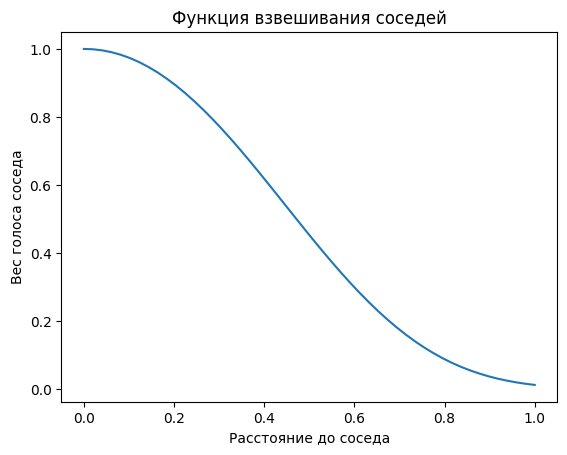

In [ ]:
x = np.linspace(0, 1)
plt.plot(x, distance2vote(x))
plt.xlabel('Расстояние до соседа')
plt.ylabel('Вес голоса соседа')
plt.title('Функция взвешивания соседей'); #чем болиже к 0 d (минимальное расстояние), тем больше вес

In [ ]:
#from tqdm.auto import tqdm, trange #печатают динамически обновляемую полосу выполнения

In [ ]:
words, vectors, synset_ids = [], [], [] #сбор данных из RuWordNet
for synset in tqdm(wn.synsets): #итерация по синсетам
    if synset.part_of_speech != 'V': #пропус всего, кроме глаголов
        continue
    for sense in synset.senses:
        words.append(sense.name)
        vectors.append(vectorize(sense.name))
        synset_ids.append(synset.id) #добавление в спиоск слов, их векторов, а также id, чтобы позднее найти гиперонимы
vectors = np.stack(vectors) #преобразует вектора в единую матрице
tree = KDTree(vectors) #строит KD-дерево, чтобы можно было эффективно искать ближайшие вектора по расстоянию

  0%|          | 0/59905 [00:00<?, ?it/s]

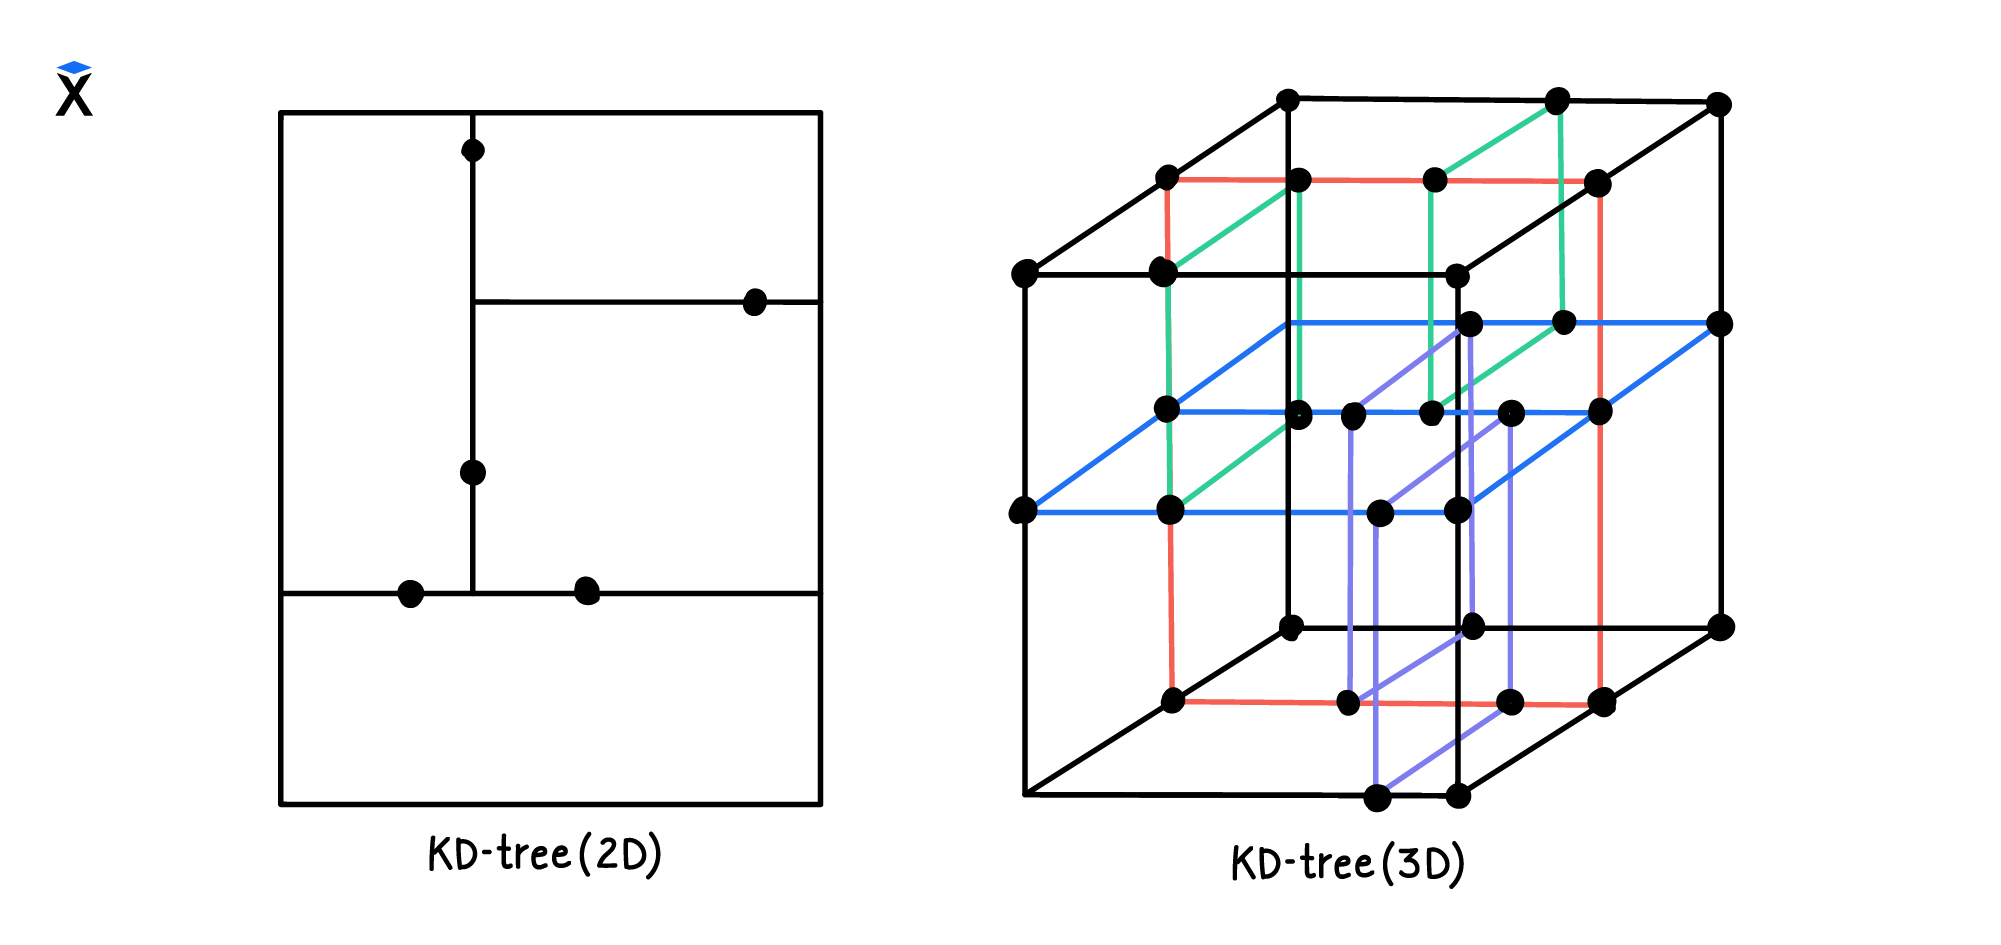![image.png]()

В KD-дереве каждый уровень дерева разделяет данные по разным измерениям, циклически проходя по всем k-измерениям. KD-Tree(K-мерное дерево), специальная 'геометрическая' структура данных, которая позволяет разбить K-мерное пространство на 'меньшие части', посредством сечения этого самого пространства гиперплоскостями(K > 3), плоскостями (K = 3), прямыми (K = 2) ну, и в случае одномерного пространства-точкой.
Такое разбиение обычно используют для сужения диапазона поиска в K-мерном пространстве.

In [ ]:
votes = Counter()
dists, ids = tree.query(vectorize('притворяться').reshape(1, -1), k=100)
for idx, distance in zip(ids[0], dists[0]):
    for hyper in wn[synset_ids[idx]].hypernyms:
        votes[hyper.id] += distance2vote(distance)
    print(words[idx], [t.title for t in wn[synset_ids[idx]].hypernyms])

ПРИТВОРЯТЬСЯ ['ОБМАНУТЬ, ВВЕСТИ В ЗАБЛУЖДЕНИЕ']
ПРИТВОРЯТЬСЯ ['ЗАТВОРИТЬСЯ, ЗАКРЫТЬСЯ']
ПРИТВОРЯТЬ ['ЗАКРЫТЬ ДВЕРЬ, ОКНО']
ПРИТВОРИТЬСЯ ['ЗАТВОРИТЬСЯ, ЗАКРЫТЬСЯ']
ПРИТВОРИТЬСЯ ['ОБМАНУТЬ, ВВЕСТИ В ЗАБЛУЖДЕНИЕ']
ОТВОРЯТЬСЯ ['РАСКРЫТЬСЯ, ОТКРЫТЬСЯ']
ОТВОРЯТЬСЯ ['ОТКРЫТЬ ОТВЕРСТИЕ, ПРОХОД']
ПРИТВОРИТЬ ['ЗАКРЫТЬ ДВЕРЬ, ОКНО']
ПРИДУРЯТЬСЯ ['ПРИТВОРИТЬСЯ, ПРИКИНУТЬСЯ']
ПРИТЫКАТЬСЯ ['ПРИСТРОИТЬСЯ (ПОМЕСТИТЬСЯ, РАСПОЛОЖИТЬСЯ, ОКОЛО ЧЕГО-Н.)']
ЦЕЛОВАТЬСЯ ['ЦЕЛОВАТЬ']
ОБМАНЫВАТЬСЯ ['ОШИБИТЬСЯ', 'ПОДВЕРГНУТЬСЯ ВОЗДЕЙСТВИЮ']
ПРИКИДЫВАТЬСЯ ['ОБМАНУТЬ, ВВЕСТИ В ЗАБЛУЖДЕНИЕ']
МАТЮГАТЬСЯ ['РУГАТЬСЯ, ВЫРУГАТЬСЯ']
РАСХНЫКАТЬСЯ ['ПЛАКАТЬ, ПРОЛИВАТЬ СЛЕЗЫ']
ПРЯТАТЬСЯ ['СОДЕРЖАТЬСЯ, ЗАКЛЮЧАТЬСЯ ВНУТРИ']
ПРЯТАТЬСЯ ['РАЗМЕСТИТЬСЯ', 'СПРЯТАТЬ, СКРЫТЬ']
ПРЯТАТЬСЯ ['УДАЛИТЬСЯ НА НЕКОТОРОЕ РАССТОЯНИЕ', 'ИСЧЕЗНУТЬ ИЗ ВИДУ']
ОТВОРЯТЬ ['ОТКРЫТЬ ОТВЕРСТИЕ, ПРОХОД']
ОБЗЫВАТЬСЯ ['ОБИДЕТЬ, ПРИЧИНИТЬ ОБИДУ', 'НАЗВАТЬ (ПРОИЗНЕСТИ)']
ЗАТВОРЯТЬСЯ ['ПОВЕРНУТЬ, ИЗМЕНИТЬ ПОЛОЖЕНИЕ']
БОЛТАТЬСЯ ['КОЛЫХАТЬСЯ']
БОЛТАТЬСЯ ['БЕЗДЕЛ

In [ ]:
for sid, score in votes.most_common(10):
    print(score,  wn[sid].title) #ранжируем наш список

1.3705729286720791 ОБМАНУТЬ, ВВЕСТИ В ЗАБЛУЖДЕНИЕ
1.3320548739806148 ЗАТВОРИТЬСЯ, ЗАКРЫТЬСЯ
0.7604945789806468 ЗАКРЫТЬ ДВЕРЬ, ОКНО
0.348603991552585 ПРИТВОРИТЬСЯ, ПРИКИНУТЬСЯ
0.2746904508053486 ОТКРЫТЬ ОТВЕРСТИЕ, ПРОХОД
0.22076542790493045 ПЕРЕЖИТЬ, ИСПЫТАТЬ
0.18363116044978076 РАСКРЫТЬСЯ, ОТКРЫТЬСЯ
0.15686516097477463 БЕЗДЕЛЬНИЧАТЬ
0.15686516097477463 БРОДИТЬ ТУДА-СЮДА
0.15490223163896144 СОДЕРЖАТЬСЯ, ЗАКЛЮЧАТЬСЯ ВНУТРИ


Найди лишнее

In [ ]:
import math


def get_all_hypernyms(wn, word, max_level=100):
    """ Return dict of all hypernyms of a word and their distances """
    front = [sense.synset for sense in wn.get_senses(word)] #front — список текущих синсетов на данном уровне поиска
    levels = {}
    for level in range(max_level):
        if not front:
            break
        new_front = []
        for synset in front:
            if synset.id not in levels:
                levels[synset.id] = level
                new_front.extend(synset.hypernyms)
        front = new_front
    return levels

def get_closest_common(levels1, levels2):
    """ Find the closest common hypernym and sum of distances to it"""
    result = None
    result_distance = math.inf
    for id, distance in levels1.items():
        if id in levels2:
            total = distance + levels2[id]
            if total < result_distance:
                result_distance = total
                result = id
    return result, result_distance

In [ ]:
words = ['ДИВАН', 'ШКАФ', 'ЛАМПА', 'СТОЛ']
print('\t\t', '\t'.join(words))
for w1 in words:
    print(w1, end='\t')
    for w2 in words:
        n, d = get_closest_common(get_all_hypernyms(wn, w1), get_all_hypernyms(wn, w2))
        print(d, end='\t\t')
    print()

		 ДИВАН	ШКАФ	ЛАМПА	СТОЛ
ДИВАН	0		3		10		3		
ШКАФ	3		0		5		2		
ЛАМПА	10		5		0		7		
СТОЛ	3		2		7		0		


In [ ]:
name, distance = get_closest_common(get_all_hypernyms(wn, 'лампа'), get_all_hypernyms(wn, 'шкаф'))
print(distance, name, wn[name].title)

5 106555-N ТЕХНИЧЕСКОЕ УСТРОЙСТВО


In [ ]:
for k, v in get_all_hypernyms(wn, 'лампа').items():
    print(k, v, wn[k])

128561-N 0 Synset(id="128561-N", title="ОСВЕТИТЕЛЬНЫЙ ПРИБОР")
8785-N 0 Synset(id="8785-N", title="ЭЛЕКТРИЧЕСКАЯ ЛАМПА")
107646-N 1 Synset(id="107646-N", title="ИСТОЧНИК ОСВЕЩЕНИЯ")
4222-N 1 Synset(id="4222-N", title="СВЕТОТЕХНИЧЕСКОЕ ОБОРУДОВАНИЕ")
106488-N 2 Synset(id="106488-N", title="ИСХОДНЫЙ ПУНКТ")
2070-N 2 Synset(id="2070-N", title="ЭЛЕКТРОТЕХНИЧЕСКОЕ ОБОРУДОВАНИЕ")
106613-N 3 Synset(id="106613-N", title="РОЛЬ, ПОЛОЖЕНИЕ, МЕСТО")
149201-N 3 Synset(id="149201-N", title="ИНЖЕНЕРНОЕ ОБОРУДОВАНИЕ")
106555-N 4 Synset(id="106555-N", title="ТЕХНИЧЕСКОЕ УСТРОЙСТВО")
1320-N 4 Synset(id="1320-N", title="ОБОРУДОВАНИЕ")
106553-N 5 Synset(id="106553-N", title="ПРИСПОСОБЛЕНИЕ (ПРЕДМЕТ)")
106554-N 6 Synset(id="106554-N", title="ПРЕДМЕТ, ВЕЩЬ")
147133-N 7 Synset(id="147133-N", title="ФИЗИЧЕСКИЙ ОБЪЕКТ")
147134-N 8 Synset(id="147134-N", title="ФИЗИЧЕСКАЯ СУЩНОСТЬ")
153782-N 9 Synset(id="153782-N", title="ПОСТОЯННАЯ СУЩНОСТЬ")


In [ ]:
wn["149201-N"].hypernyms

[Synset(id="106555-N", title="ТЕХНИЧЕСКОЕ УСТРОЙСТВО"),
 Synset(id="1320-N", title="ОБОРУДОВАНИЕ")]

In [ ]:
for k, v in get_all_hypernyms(wn, 'стол').items():
    print(k, v, wn[k])

146834-N 0 Synset(id="146834-N", title="СТОЛ ДЛЯ ЕДЫ")
107294-N 0 Synset(id="107294-N", title="СТОЛ")
106554-N 1 Synset(id="106554-N", title="ПРЕДМЕТ, ВЕЩЬ")
1253-N 1 Synset(id="1253-N", title="МЕБЕЛЬ")
147133-N 2 Synset(id="147133-N", title="ФИЗИЧЕСКИЙ ОБЪЕКТ")
130019-N 2 Synset(id="130019-N", title="НЕПРОДОВОЛЬСТВЕННЫЕ ТОВАРЫ")
146828-N 2 Synset(id="146828-N", title="ПРЕДМЕТ ИНТЕРЬЕРА")
9059-N 2 Synset(id="9059-N", title="ПРОДУКЦИЯ ДЕРЕВООБРАБОТКИ")
147134-N 3 Synset(id="147134-N", title="ФИЗИЧЕСКАЯ СУЩНОСТЬ")
1252-N 3 Synset(id="1252-N", title="ПОТРЕБИТЕЛЬСКИЕ ТОВАРЫ")
56-N 3 Synset(id="56-N", title="ПРОМЫШЛЕННАЯ ПРОДУКЦИЯ")
562-N 3 Synset(id="562-N", title="ТОВАР")
106507-N 3 Synset(id="106507-N", title="ПРОДУКТ ПРОИЗВОДСТВА")
153782-N 4 Synset(id="153782-N", title="ПОСТОЯННАЯ СУЩНОСТЬ")
106505-N 4 Synset(id="106505-N", title="ПРОДУКТ ТРУДА")


Разрешение неоднозначности

In [ ]:
!pip install razdel
import razdel

In [ ]:
context = '''Сначала шов слегка уплотняем молоточком, затем прочеканиваем на нём замок
― бороздку, называемую "зигом", которая будет препятствовать расхождению шва при дальнейшем его уплотнении.'''
word = 'замок'

In [ ]:
def disambiguate(word, context):
    candidates = [s.synset for s in wn[word]]
    text_vector = vectorize(' '.join(t.text for t in razdel.tokenize(context) if t.text != word))
    candidate_vectors = [
        vectorize(' '.join(w for s in c.senses for w in s.name.lower().split() if name != word))
        for c in candidates
    ]
    scores = [np.dot(text_vector, v) for v in candidate_vectors]
    return dict(zip(scores, candidates))

disambiguate(word, context)

{0.4421322748905842: Synset(id="126228-N", title="СРЕДНЕВЕКОВЫЙ ЗАМОК"),
 0.55319632362594: Synset(id="114707-N", title="ЗАМОК ДЛЯ ЗАПИРАНИЯ")}

In [ ]:
context = '''Издали видны королевский замок Вавель и кафедральный собор Святых Вацлава и Станислава
― настоящие шедевры зодчества.'''
disambiguate(word, context)

{0.6623339070392336: Synset(id="126228-N", title="СРЕДНЕВЕКОВЫЙ ЗАМОК"),
 0.5569728387813146: Synset(id="114707-N", title="ЗАМОК ДЛЯ ЗАПИРАНИЯ")}

Мой проект: Кластеризация значений многозначного слова

In [ ]:
sentences = [
    "Он вставил ключ в замок и открыл дверь.",
    "В кармане шуршал металлический ключ от квартиры.",
    "Без этого ключа сейф невозможно открыть.",
    "Я потерял ключ от машины и вызвал эвакуатор.",
    "Охранник носит связку ключей от всех помещений.",

    "Из-под земли бил холодный ключ.",
    "Ключ с чистой водой струился у подножия горы.",
    "Деревня расположена рядом с целебным ключом.",
    "Мы набрали воды из родникового ключа.",
    "У ключа паслись коровы и лошади.",

    "Ключ к задаче — внимательное чтение условия.",
    "Разговор с бабушкой стал ключом к пониманию истории семьи.",
    "Этот метод — ключ к успешной работе алгоритма.",
    "Знание языка — ключ к карьерному росту.",
    "Найдите ключевую идею в тексте.",

    "Введите ключ активации, чтобы продолжить установку.",
    "У каждого пользователя свой уникальный API-ключ.",
    "Без правильного шифровального ключа данные не расшифровать.",
    "Секретный ключ хранится в защищённой области памяти.",
    "Пожалуйста, не передавайте свой лицензионный ключ другим.",

    "В музыкальной строке стоит скрипичный ключ.",
    "Нота фа размещается на второй линии под басовым ключом.",
    "В начале каждой строки указывается ключ.",
    "Скрипичный ключ определяет положение ноты соль.",
    "Для фортепиано чаще всего используется два ключа — скрипичный и басовый.",

    "Ключ к победе — это командная работа.",
    "Он дал мне ключ к решению этой головоломки.",
    "Ключ к пониманию книги — её символизм.",
    "Для разработки стратегии нужно найти ключевое звено.",
    "Этот индикатор — ключ к прогнозу ситуации на рынке."]

In [ ]:
def vectorize_context(text):
  words = [w for w in text.lower().split() if len(w) >= 3]
  vecs = [ft_model[word] for word in words if word in ft_model]
  return np.mean(vecs, axis=0) if vecs else np.zeros(ft_model.dim)

In [ ]:
from sklearn.cluster import KMeans

X = np.stack([vectorize_context(s) for s in sentences])
kmeans = KMeans(n_clusters=3, random_state=42).fit(X)
labels = kmeans.labels_

In [ ]:
for label in set(labels):
    print(f"\nКластер {label}")
    for i, s in enumerate(sentences):
        if labels[i] == label:
            print("-", s)


Кластер 0
- Ключ с чистой водой струился у подножия горы.
- Деревня расположена рядом с целебным ключом.
- Мы набрали воды из родникового ключа.
- У ключа паслись коровы и лошади.
- Разговор с бабушкой стал ключом к пониманию истории семьи.
- Секретный ключ хранится в защищённой области памяти.
- В музыкальной строке стоит скрипичный ключ.
- Нота фа размещается на второй линии под басовым ключом.
- Он дал мне ключ к решению этой головоломки.
- Ключ к пониманию книги — её символизм.

Кластер 1
- Без этого ключа сейф невозможно открыть.
- Ключ к задаче — внимательное чтение условия.
- Этот метод — ключ к успешной работе алгоритма.
- Знание языка — ключ к карьерному росту.
- Найдите ключевую идею в тексте.
- Введите ключ активации, чтобы продолжить установку.
- У каждого пользователя свой уникальный API-ключ.
- Без правильного шифровального ключа данные не расшифровать.
- Пожалуйста, не передавайте свой лицензионный ключ другим.
- В начале каждой строки указывается ключ.
- Скрипичный клю

In [ ]:
for sense in wn.get_senses('ключ'):
    print(sense.synset)

Synset(id="146874-N", title="ГАЕЧНЫЙ КЛЮЧ")
Synset(id="141994-N", title="КЛЮЧ ШИФРОВАНИЯ")
Synset(id="154325-N", title="КЛЮЧ ДЛЯ ПОНИМАНИЯ, ОВЛАДЕНИЯ")
Synset(id="109795-N", title="МУЗЫКАЛЬНЫЙ КЛЮЧ")
Synset(id="109799-N", title="ВОДНЫЙ ИСТОЧНИК")
Synset(id="114704-N", title="КЛЮЧ К ЗАМКУ")
